# LFYKI1101 - Capteurs, Actionneurs et Instrumentation
## Labo ATD - Mars 2026
### Analyse Thermique Différentielle (ATD) - Transitions de phase du gallium

**Notebook template** basé sur l'énoncé du labo.

- Étudiant : ...
- Groupe : ...
- Date : ...

---

## 1. Contexte expérimental

Le gallium (Ga, Z = 31) est un métal dont le point de fusion se situe légèrement au-dessus de la température ambiante (**T_f = 29.76 °C**).  
Le montage expérimental repose sur le principe de l'**Analyse Thermique Différentielle (ATD)**, avec deux capteurs TMP117 :

- **T1** : capteur de référence
- **T2** : capteur en contact thermique avec l'échantillon de gallium
- **Signal différentiel** : **ΔT = T1 - T2**

Le cycle expérimental comporte une **chauffe** puis un **refroidissement**.

---

## 2. Questions


In [1]:
# Imports de base
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Affichage plus lisible
pd.set_option("display.max_columns", None)
pd.set_option("display.precision", 4)

# À adapter avec le vrai nom de votre fichier CSV
csv_path = "tmp117_log_labo_6mars.csv"


## 2.1. Prise en main des données

### Q1. Chargez le fichier CSV avec pandas. Affichez les premières lignes et vérifiez les types de données. Combien de points de mesure le fichier contient-il ? Quelle est la durée totale de l’expérience ?

In [2]:
# Q1 - Chargement des données
df = pd.read_csv(csv_path)

# Aperçu
display(df.head())

# Types
print(df.dtypes)

# Nombre de points
n_points = len(df)
print("Nombre de points :", n_points)

# Durée totale
duree_totale = df["Elapsed_Time_s"].iloc[-1] - df["Elapsed_Time_s"].iloc[0]
print("Durée totale de l'expérience [s] :", duree_totale)


,Elapsed_Time_s,Timestamp,T1_C,T2_C,Skew_ms,Delta_T_C
0,0.000,2026-03-06T12:07:31.375616,-9.5391,-9.3125,0.854,-0.2266
1,0.225,2026-03-06T12:07:31.600212,-9.5313,-9.3047,0.854,-0.2266
2,0.468,2026-03-06T12:07:31.843381,-9.5234,-9.3047,0.824,-0.2188
3,0.708,2026-03-06T12:07:32.083552,-9.5234,-9.2969,0.854,-0.2266
4,0.946,2026-03-06T12:07:32.321221,-9.5156,-9.3047,0.885,-0.2109


Elapsed_Time_s    float64
Timestamp             str
T1_C              float64
T2_C              float64
Skew_ms           float64
Delta_T_C         float64
dtype: object
Nombre de points : 4295
Durée totale de l'expérience [s] : 1016.199


**Réponse / interprétation :**

- Nombre de points : ...
- Durée totale : ...
- Commentaire sur les types de données : ...


### Q2. Calculez l’intervalle d’échantillonnage moyen et son écart-type à partir de la colonne Elapsed_Time_s. Comparez avec la fréquence d’échantillonnage nominale de 4 Hz. La mesure est-elle régulière ? Que révèle la colonne Skew_ms sur la synchronisation des deux capteurs ?

Intervalle moyen [s] : 0.23665556590591522
Écart-type de dt [s] : 0.009783583920006247
Fréquence moyenne [Hz] : 4.225550310519888

Résumé de Skew_ms :


count    4295.0000
mean        0.8635
std         0.0677
min         0.8240
25%         0.8540
50%         0.8540
75%         0.8540
max         2.1060
Name: Skew_ms, dtype: float64

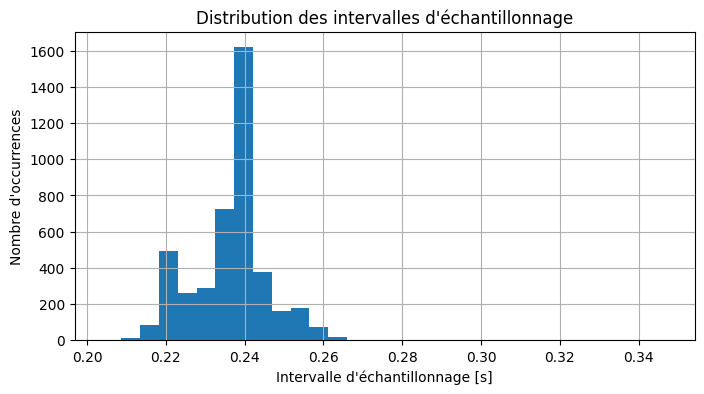

In [3]:
# Q2 - Analyse de l'échantillonnage
dt = df["Elapsed_Time_s"].diff().dropna()

dt_moyen = dt.mean()
dt_std = dt.std()

f_moyenne = 1 / dt_moyen

print("Intervalle moyen [s] :", dt_moyen)
print("Écart-type de dt [s] :", dt_std)
print("Fréquence moyenne [Hz] :", f_moyenne)

# Analyse simple de la colonne Skew_ms
print("\nRésumé de Skew_ms :")
display(df["Skew_ms"].describe())

# Histogramme optionnel
plt.figure(figsize=(8,4))
plt.hist(dt, bins=30)
plt.xlabel("Intervalle d'échantillonnage [s]")
plt.ylabel("Nombre d'occurrences")
plt.title("Distribution des intervalles d'échantillonnage")
plt.grid(True)
plt.show()


**Réponse / interprétation :**

- Intervalle moyen : ...
- Écart-type : ...
- Fréquence nominale attendue : 4 Hz -> période de 0.25 s
- Régularité de la mesure : ...
- Interprétation de `Skew_ms` : ...


## 2.2. Visualisation et identification des régimes

### Q3. Tracez T1(t) et T2(t) sur le même graphe (axes légendés, unités). Identifiez et délimitez visuellement les deux régimes de l’expérience : chauffe et refroidissement.

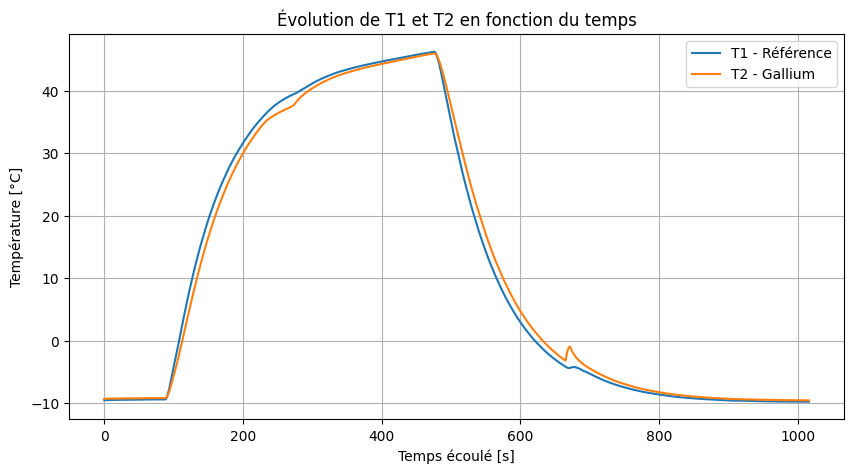

In [4]:
# Q3 - Tracé de T1(t) et T2(t)
plt.figure(figsize=(10,5))
plt.plot(df["Elapsed_Time_s"], df["T1_C"], label="T1 - Référence")
plt.plot(df["Elapsed_Time_s"], df["T2_C"], label="T2 - Gallium")
plt.xlabel("Temps écoulé [s]")
plt.ylabel("Température [°C]")
plt.title("Évolution de T1 et T2 en fonction du temps")
plt.legend()
plt.grid(True)
plt.show()

# Option : estimer visuellement l'instant de bascule chauffe -> refroidissement
# t_bascule = ...


**Réponse / interprétation :**

- Régime de chauffe : de ... s à ... s
- Régime de refroidissement : de ... s à ... s
- Justification visuelle : ...


### Q4. Tracez ΔT(t) = T1(t) - T2(t) en fonction du temps. Décrivez qualitativement l’allure de la courbe. Où se situent les anomalies les plus marquées ?

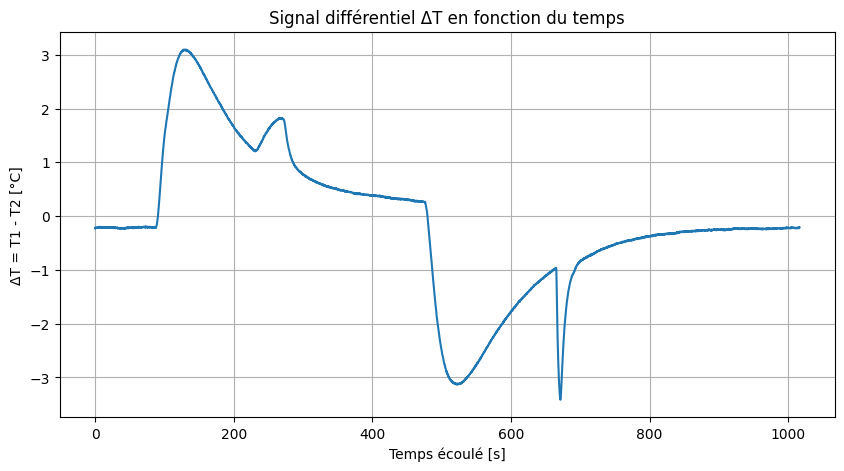

In [5]:
# Q4 - Tracé de Delta_T(t)
plt.figure(figsize=(10,5))
plt.plot(df["Elapsed_Time_s"], df["Delta_T_C"])
plt.xlabel("Temps écoulé [s]")
plt.ylabel("ΔT = T1 - T2 [°C]")
plt.title("Signal différentiel ΔT en fonction du temps")
plt.grid(True)
plt.show()


**Réponse / interprétation :**

- Allure générale : ...
- Anomalies principales observées vers ... s et ... s
- Lien possible avec fusion / solidification : ...


## 2.3. Principe physique de l’ATD

### Q5. Lors de la fusion du gallium, T2 absorbe la chaleur latente et sa montée en température ralentit par rapport à T1. Expliquez, à partir d’un bilan enthalpique, pourquoi ΔT = T1 - T2 devient positif à la fusion et négatif à la solidification. Schématisez la situation.

**Réponse théorique (à compléter) :**

Rédiger ici le bilan enthalpique et l'explication physique.

- À la fusion : ...
- À la solidification : ...
- Schéma / explication qualitative : ...


### Q6. Quel est l’avantage de mesurer ΔT plutôt que T2 seul pour détecter une transition de phase ? En quoi ce principe est-il analogue à celui d’une DSC (Differential Scanning Calorimetry) utilisée en recherche ?

**Réponse théorique (à compléter) :**

- Avantage du signal différentiel : ...
- Comparaison avec la DSC : ...


## 2.4. Extraction des grandeurs caractéristiques

### Q7. À partir de la courbe T2(t), estimez la température de fusion du gallium. Comparez avec la valeur tabulée (Tf = 29.76°C) et calculez l’écart relatif. Discutez les sources d’incertitude (résolution du capteur, contact thermique, vitesse de chauffe).

In [6]:
# Q7 - Estimation de la température de fusion
T_f_tabulee = 29.76  # °C

# Méthode à définir : plateau, moyenne locale, sélection manuelle, etc.
# Exemple :
# indices_plateau = ...
# T_f_estimee = df.loc[indices_plateau, "T2_C"].mean()

T_f_estimee = np.nan  # À remplacer
ecart_relatif = abs(T_f_estimee - T_f_tabulee) / T_f_tabulee if not np.isnan(T_f_estimee) else np.nan

print("Température de fusion estimée [°C] :", T_f_estimee)
print("Écart relatif :", ecart_relatif)


Température de fusion estimée [°C] : nan
Écart relatif : nan


**Réponse / interprétation :**

- Température de fusion estimée : ...
- Valeur tabulée : 29.76 °C
- Écart relatif : ...
- Sources d'incertitude : ...


### Q8. À partir de la courbe ΔT(t), relevez pour chaque transition (fusion et solidification) : le début, la fin, la durée du plateau, et la valeur maximale de |ΔT|. Présentez vos résultats dans un tableau récapitulatif.

In [7]:
# Q8 - Extraction des caractéristiques des transitions
# Définir les fenêtres de transition à partir de l'analyse graphique ou d'un critère numérique

# Exemple de structure à compléter :
resultats_q8 = pd.DataFrame({
    "Transition": ["Fusion", "Solidification"],
    "t_debut_s": [np.nan, np.nan],
    "t_fin_s": [np.nan, np.nan],
    "duree_s": [np.nan, np.nan],
    "max_abs_DeltaT_C": [np.nan, np.nan],
})

display(resultats_q8)


,Transition,t_debut_s,t_fin_s,duree_s,max_abs_DeltaT_C
0,Fusion,NaN,NaN,NaN,NaN
1,Solidification,NaN,NaN,NaN,NaN


**Réponse / interprétation :**

Compléter et commenter le tableau récapitulatif.


### Q9. Observez-vous un phénomène de surfusion (supercooling) lors de la solidification sur la courbe T2(t) ? Si oui, estimez son amplitude ΔT_surf et sa durée. Expliquez brièvement le mécanisme physique à l’origine de ce phénomène.

In [8]:
# Q9 - Analyse de la surfusion
# Identifier une éventuelle température de solidification inférieure à la température d'équilibre

Delta_T_surf = np.nan
duree_surf = np.nan

print("Amplitude de surfusion [°C] :", Delta_T_surf)
print("Durée de la surfusion [s] :", duree_surf)


Amplitude de surfusion [°C] : nan
Durée de la surfusion [s] : nan


**Réponse / interprétation :**

- Surfusion observée ? ...
- Amplitude : ...
- Durée : ...
- Mécanisme physique : ...


## 2.5. Estimation de la chaleur latente (question ouverte)

### Q10. En supposant une puissance de chauffe constante P, proposez et appliquez une méthode pour estimer qualitativement la chaleur latente de fusion du gallium Lf à partir de la pente de T1(t) hors transition, de la durée du plateau de fusion, et de la masse approximative de l’échantillon.

In [9]:
# Q10 - Estimation qualitative de la chaleur latente
L_f_tabulee = 80.1e3  # J/kg

# Masse de l'échantillon (à compléter avec la valeur fournie par l'assistant)
m = np.nan  # kg

# Exemple de variables à estimer
pente_T1 = np.nan           # K/s
duree_plateau_fusion = np.nan  # s

# Construire ici votre modèle / estimation
L_f_estimee = np.nan  # J/kg

print("Pente de T1 hors transition [K/s] :", pente_T1)
print("Durée du plateau de fusion [s] :", duree_plateau_fusion)
print("Chaleur latente estimée [J/kg] :", L_f_estimee)
print("Valeur tabulée [J/kg] :", L_f_tabulee)

if not np.isnan(L_f_estimee):
    print("Écart relatif :", abs(L_f_estimee - L_f_tabulee) / L_f_tabulee)


Pente de T1 hors transition [K/s] : nan
Durée du plateau de fusion [s] : nan
Chaleur latente estimée [J/kg] : nan
Valeur tabulée [J/kg] : 80100.0


**Réponse / discussion :**

- Méthode proposée : ...
- Hypothèses : ...
- Valeur estimée : ...
- Comparaison à 80.1 kJ/kg : ...
- Limites de l'approche : ...


## 3. Livrables attendus

## Checklist finale

- [ ] Toutes les cellules de code sont exécutées sans erreur
- [ ] Les graphes ont des axes, unités, titres et légendes
- [ ] Les réponses rédigées sont complétées
- [ ] Le tableau récapitulatif de la Q8 est rempli
- [ ] La discussion critique finale est ajoutée

## Rappel des données utiles

- Point de fusion du gallium : **29.76 °C**
- Chaleur latente de fusion : **80.1 kJ/kg**
- Chaleur spécifique (solide) : **0.372 J/(g.K)**
- Résolution TMP117 : **7.8 m°C**
- Précision TMP117 : **±0.1 °C**
